RFM ANALYSIS


Companies use this to:

identify VIP customers,
target inactive users,
improve marketing campaigns.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "C:/Users/Sneha/OneDrive/Desktop/Data Analytics/E-Commerce/data/cleaned_ecommerce_data.csv"
)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,Day,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday


We need a date to calculate:
recency

Usually:
latest transaction + 1 day

In [3]:

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(reference_date)


2011-12-10 12:50:00


CREATE RFM TABLE



RECENCY:

How recently customer purchased.

FREQUENCY:

How many orders customer made.

MONETARY:

Total customer spending.

In [4]:
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x:
        (reference_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'Sales': 'sum'

}).reset_index()

In [7]:
#RENAME COLUMNS


rfm.columns = [

    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'

]

rfm.head(5)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


EDA ON RFM

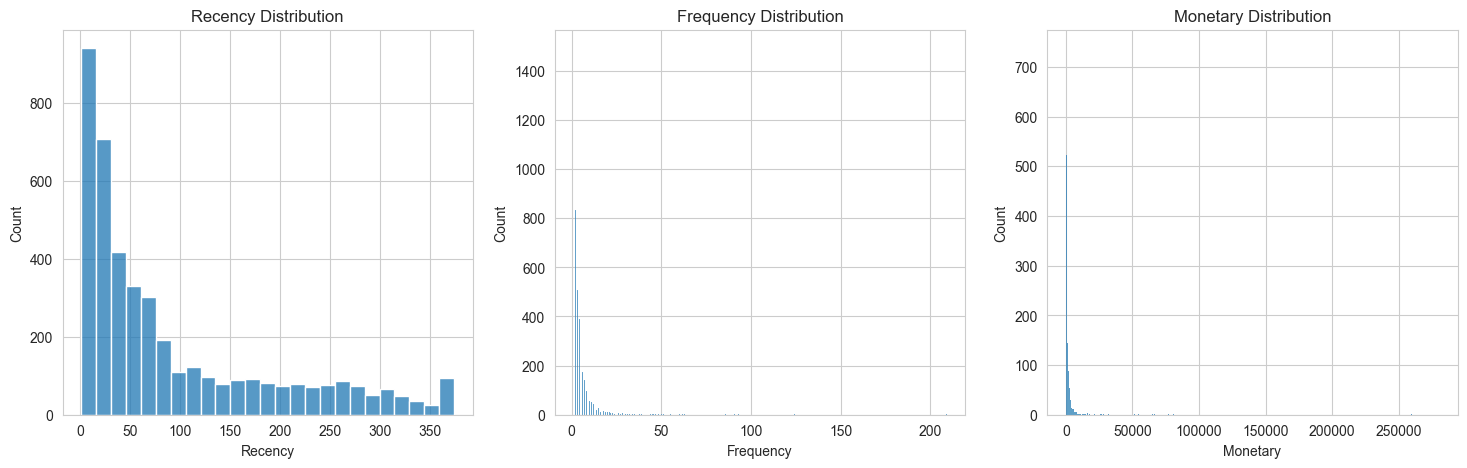

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm['Recency'], ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm['Frequency'], ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm['Monetary'], ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.show()

| Graph     | Meaning                  |
| --------- | ------------------------ |
| Recency   | days since last purchase |
| Frequency | number of purchases      |
| Monetary  | total customer spending  |


1. RECENCY DISTRIBUTION

    OBSERVATION:
- Most customers made purchases recently, indicating active customer engagement.
- However, a significant number of customers show high recency values, suggesting inactivity or possible customer churn.
- The business may benefit from retention campaigns targeting inactive customers.

2. FREQUENCY DISTRIBUTION 

    OBSERVATION:
    
- Most customers place only a small number of orders.
- A limited group of customers contributes frequent repeat purchases.
- Repeat customers are likely responsible for a significant portion of business revenue.
- Customer loyalty strategies could help increase repeat purchasing behavior.
- This is a heavily right-skewed distribution (VERY common in e-commerce)

3. MONETARY DISTRIBUTION

    OBSERVATION:
- Customer spending is highly concentrated among a small number of high-value customers.
- Most customers contribute relatively low monetary value.
- A few customers generate exceptionally high revenue, creating strong positive skewness.
- High-value customer retention is critical for sustaining business profitability.
- small percentage of customers generate major revenue [This is EXTREMELY common in business]

SCALING FOR CLUSTERING


In [9]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(

    rfm[['Recency', 'Frequency', 'Monetary']]

)

FIND OPTIMAL CLUSTERS USING ELBOW METHOD

In [10]:
inertia = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

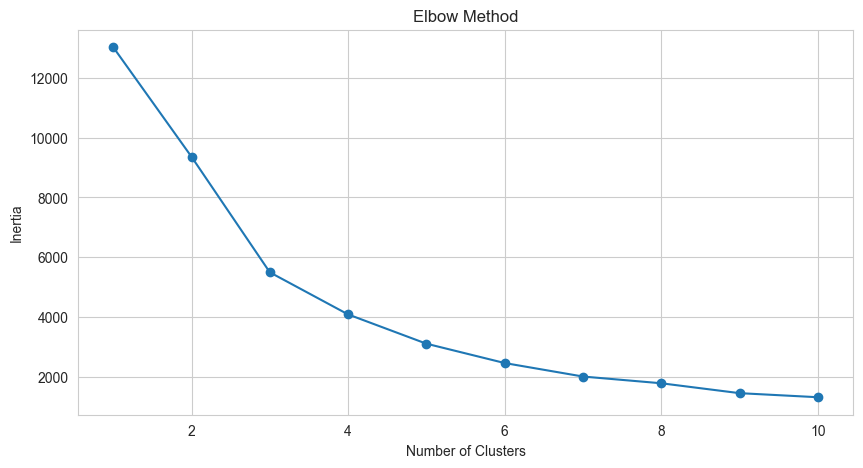

In [11]:
plt.figure(figsize=(10,5))

plt.plot(K, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

OBSERVATION:
- The elbow point helps identify the optimal number of customer segments.
- A cluster count around 3–5 usually provides meaningful business segmentation.

In [12]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

In [13]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


In [14]:
cluster_summary = rfm.groupby('Cluster')[

    ['Recency', 'Frequency', 'Monetary']

].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


INTERPRET CLUSTERS

Example interpretation:
                         
High Monetary + High Frequency ---> VIP Customers


High Recency + Low Spending	 ---> Inactive Customers


Medium Everything --->	Regular Customers

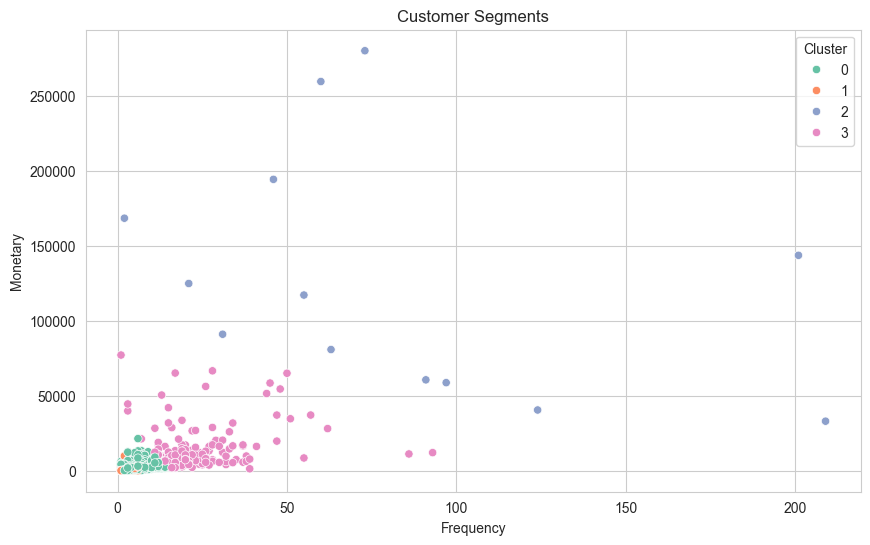

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments")

plt.show()

| Cluster            | Likely Meaning                    |
| ------------------ | --------------------------------- |
| Cluster 2 (blue)   | VIP / High-value customers        |
| Cluster 3 (pink)   | Regular customers                 |
| Cluster 0 (green)  | Low-value occasional buyers       |
| Cluster 1 (orange) | Very low engagement/new customers |


OBSERVATION:
- The clustering algorithm successfully identified distinct customer groups based on purchase frequency and monetary spending.
- One cluster contains high-frequency and high-spending customers, representing VIP or premium customers who contribute significantly to overall revenue.
- Another large cluster contains moderate-frequency and moderate-spending customers, indicating regular customers with stable purchasing behavior.
- Some customers exhibit low frequency and low monetary value, representing occasional or low-engagement buyers.
- The presence of extreme high-spending outliers suggests that a small number of customers generate disproportionately large revenue.
- These customer segments can help businesses design personalized marketing campaigns, loyalty programs, and retention strategies.


BUSINESS INSIGHT:
- High-value customers should be prioritized through premium services and personalized offers.
- Low-frequency customers can be targeted with re-engagement campaigns and discounts.
- Regular customers represent growth opportunities and can be converted into loyal customers through targeted retention strategies.
- Customer segmentation enables more efficient marketing and improves customer lifetime value.

In [16]:
rfm.to_csv(
    "C:/Users/Sneha/OneDrive/Desktop/Data Analytics/E-Commerce/data/customer_segments.csv",
    index=False
)